# TFCE + WTA — Cross-Sectional Group-Level

Group-level patient vs control comparisons of full-VOTC WTA maps using
Liu contrasts and MNI zstats. Tests how voxel allegiance differs between
groups beyond peak displacement and sum-selectivity.

**Sample (cross-sectional):**
- Controls (n≈38): both hemispheres
- OTC patients only (nonOTC excluded), intact hemisphere
- One session per subject (first available post-surgery)

**Analyses (group-level perm tests, 10k permutations, seed 42):**
1. WTA territory % per category × hemisphere
2. Pairwise category neighborhood (boundary preservation)
3. Control-defined territory displacement (where does territory go in patients?)
4. WTA margin distributions per category × hemisphere

**Pipeline alignment:**
- Liu contrasts: cope 1=Face>Object, 2=House>Object, 3=Object>Scramble, −cope 13=Word>Face
- Pre-registered MNI zstats from `13_register_zstats_mni.py`
- WTA threshold z > 2.326
- VOTC mask: Harvard-Oxford labels (MNI 2mm)

In [62]:
# ─── Setup: imports + paths ──────────────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ─── Choose run + correction method ──────────────────────────────────────
# CORRECTION: 'tfce' uses rand_tfce_corrp_tstat{N}.nii.gz
#             'cluster' uses rand_clustere_corrp_tstat{N}.nii.gz
CORRECTION = 'tfce'   # 'tfce' or 'cluster'

# Reference runs:
#   tfce_votc             — cat-vs-others, no threshold, TFCE-FWE
#   tfce_votc_catbaseline — cat-vs-baseline + Ayzenberg threshold, TFCE-FWE
#   tfce_votc_fdr         — cat-vs-others + thresh 0, TFCE-FWE (FDR-compatible)
#   tfce_votc_cluster     — cat-vs-others + thresh 0, cluster-extent FWE @ t>3.09
TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc_fdr'

CORRP_PATTERN = {
    'tfce':    'rand_tfce_corrp_tstat{tstat}.nii.gz',
    'cluster': 'rand_clustere_corrp_tstat{tstat}.nii.gz',
}[CORRECTION]

print(f'TFCE outputs: {TFCE_DIR}')
print(f'  exists:     {TFCE_DIR.exists()}')
print(f'  correction: {CORRECTION}  ({CORRP_PATTERN})')

# ─── Quick sanity check — surviving voxels per test ──────────────────────
print(f'\nSurviving voxels per test (FWE p<.05):')
for test_dir in sorted(TFCE_DIR.glob('*_pt_vs_ctrl')):
    for tstat, label in [(1, 'ctrl>pt'), (2, 'pt>ctrl')]:
        f = test_dir / CORRP_PATTERN.format(tstat=tstat)
        if f.exists():
            n_sig = int((nib.load(f).get_fdata() > 0.95).sum())
            if n_sig > 0:
                print(f"  {test_dir.name:<25} {label:>8}: {n_sig:>4} vox")

TFCE outputs: /user_data/csimmon2/sym_pt/group_results/tfce_votc_fdr
  exists:     True
  correction: tfce  (rand_tfce_corrp_tstat{tstat}.nii.gz)

Surviving voxels per test (FWE p<.05):
  house_r_pt_vs_ctrl         ctrl>pt:  480 vox
  object_l_pt_vs_ctrl        ctrl>pt:  437 vox
  word_r_pt_vs_ctrl          pt>ctrl:  663 vox


In [59]:
# ─── Crawford-Howell single-case face response in FFA (LH + RH) ─────────
# For each patient, tests their face zstat in their intact hemisphere's
# FFA against the control distribution at the same ROI. Identifies
# patients with individually elevated face response (RH→LH or LH→RH
# reorganization).
#
# Summary measure per subject: mean face zstat within selective voxels
# (z > 2.326) in FFA. Other options: peak zstat, sum-selectivity.

from scipy.stats import t as student_t

# Reuse subject loader + zstat path from WTA cell
assert 'load_subjects_xs' in dir() and 'subjects' in dir(), \
    "Run WTA compute cell first (defines subjects and helpers)"

# ── FFA mask (Harvard-Oxford temporal fusiform, hemi-split) ────────
ho = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho.maps if isinstance(ho.maps, nib.Nifti1Image) else nib.load(ho.maps)
ho_data = ho_img.get_fdata()
ho_labels = ho.labels

# FFA = Temporal Fusiform Cortex anterior + posterior (HO indices ~37-38)
ffa_names = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
]
ffa_full = np.zeros(ho_data.shape, dtype=bool)
for name in ffa_names:
    matches = [i for i, l in enumerate(ho_labels) if name in l]
    if matches:
        ffa_full |= (ho_data == matches[0])

# Use SAME masks as TFCE script (load from disk to avoid hemi convention issues)
votc_l_full = nib.load(TFCE_DIR / 'votc_l_mask.nii.gz').get_fdata() > 0.5
votc_r_full = nib.load(TFCE_DIR / 'votc_r_mask.nii.gz').get_fdata() > 0.5
# Intersect FFA with each hemi's VOTC mask convention
FFA_LH = ffa_full & votc_l_full
FFA_RH = ffa_full & votc_r_full
print(f'FFA voxels — LH: {FFA_LH.sum()}, RH: {FFA_RH.sum()}')

# ── Per-subject face response in each FFA ────────────────────────
SEL_THRESH = 2.326

def face_response_in_ffa(sid, ses, hemi_mask):
    """Mean face zstat (cope15) at selective voxels within hemi-FFA mask.
    Returns NaN if no selective voxels."""
    p = os.path.join(processed_dir, sid, f'ses-{ses}', 'derivatives', 'fsl',
                     'loc', 'HighLevel.gfeat', 'cope15.feat', 'stats',
                     'zstat1_mni.nii.gz')
    if not os.path.exists(p):
        return np.nan
    z = nib.load(p).get_fdata()
    z_in_ffa = z[hemi_mask]
    selective = z_in_ffa > SEL_THRESH
    return float(np.mean(z_in_ffa[selective])) if selective.any() else np.nan

# Build per-subject face response in LH FFA and RH FFA
records = []
for sid, info in subjects.items():
    for hemi, mask in [('l', FFA_LH), ('r', FFA_RH)]:
        val = face_response_in_ffa(sid, info['session'], mask)
        records.append({'sid': sid, 'hemi': hemi, 'group': info['group'],
                        'intact_hemi': info.get('intact_hemi', 'both'),
                        'face_mean_z': val})
ffa_df = pd.DataFrame(records)

# ── Crawford-Howell tests per patient (only intact hemi) ─────────
def crawford_howell(case, ctrl_mean, ctrl_sd, n_ctrl):
    t = (case - ctrl_mean) / (ctrl_sd * np.sqrt((n_ctrl + 1) / n_ctrl))
    df = n_ctrl - 1
    p_one = 1 - student_t.cdf(t, df)   # one-sided: case > ctrl
    return t, p_one

print(f"\n{'patient':<10} {'hemi':>5} {'face_z':>8} "
      f"{'ctrl_mean':>10} {'ctrl_sd':>8} {'t':>6} {'p':>8} {'sig':>5}")
print('-' * 70)
ch_results = []
for hemi in ['l', 'r']:
    ctrl_vals = ffa_df[(ffa_df['hemi']==hemi) & (ffa_df['group']=='control')]['face_mean_z'].dropna()
    n_ctrl = len(ctrl_vals)
    ctrl_mean = ctrl_vals.mean()
    ctrl_sd = ctrl_vals.std(ddof=1)
    pt_rows = ffa_df[(ffa_df['hemi']==hemi) & (ffa_df['group']=='OTC')]
    for _, r in pt_rows.iterrows():
        if r['intact_hemi'] != ('left' if hemi=='l' else 'right'):
            continue   # only intact hemi
        if np.isnan(r['face_mean_z']):
            continue
        t, p = crawford_howell(r['face_mean_z'], ctrl_mean, ctrl_sd, n_ctrl)
        sig = '*' if p < 0.05 else ''
        print(f"{r['sid']:<10} {hemi.upper():>5} {r['face_mean_z']:>8.2f} "
              f"{ctrl_mean:>10.2f} {ctrl_sd:>8.2f} {t:>6.2f} {p:>8.4f} {sig:>5}")
        ch_results.append({'sid': r['sid'], 'hemi': hemi, 't': t, 'p': p,
                           'case_z': r['face_mean_z']})

ch_df = pd.DataFrame(ch_results)
n_sig = (ch_df['p'] < 0.05).sum()
print(f'\n{n_sig}/{len(ch_df)} patients show elevated face response in intact-hemi FFA (p<.05, one-tailed)')

FFA voxels — LH: 1189, RH: 1015

patient     hemi   face_z  ctrl_mean  ctrl_sd      t        p   sig
----------------------------------------------------------------------
sub-004        L     2.69       5.10     1.28  -1.85   0.9639      
sub-005        L     4.64       5.10     1.28  -0.36   0.6388      
sub-008        L     2.40       5.10     1.28  -2.08   0.9775      
sub-039        L     7.29       5.10     1.28   1.68   0.0505      
sub-074        L     2.99       5.10     1.28  -1.62   0.9432      
sub-075        L     3.62       5.10     1.28  -1.14   0.8683      
sub-076        L     5.73       5.10     1.28   0.48   0.3155      
sub-079        L     7.16       5.10     1.28   1.59   0.0605      
sub-089        L     5.45       5.10     1.28   0.27   0.3960      
sub-044        R     3.63       3.97     0.85  -0.39   0.6497      
sub-078        R     2.63       3.97     0.85  -1.55   0.9354      
sub-082        R     3.87       3.97     0.85  -0.11   0.5422      
sub-092     

Face-winning voxels per subject (WTA, threshold z>2.326):
group       hemi   n  mean_n_face  sd_n_face              mean_centroid_xyz
--------------------------------------------------------------------------------
control        L  38        554.9      535.4   (  -32,   -64,     3)
OTC            L  11        637.3      978.4   (  -31,   -66,     0)
control        R  38        368.6      272.3   (   31,   -61,    -3)
OTC            R  11        230.5      199.4   (   27,   -63,    11)

Per-patient face-winner detail:
sid           intact  n_face                mni_xyz  extent_mm
sub-004            L      74       ( -46, -70,   2)       60.2
sub-005            L     689       ( -18, -64, -11)      122.7
sub-008            L     791       ( -28, -74,  10)       84.7
sub-010            R     164       (  12, -75,   2)      104.9
sub-021            R      86       (   1, -78,   1)       26.4
sub-039            L     274       ( -34, -72,  -3)      142.4
sub-044            R     647       

/tmp/ipykernel_3245307/1432292130.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


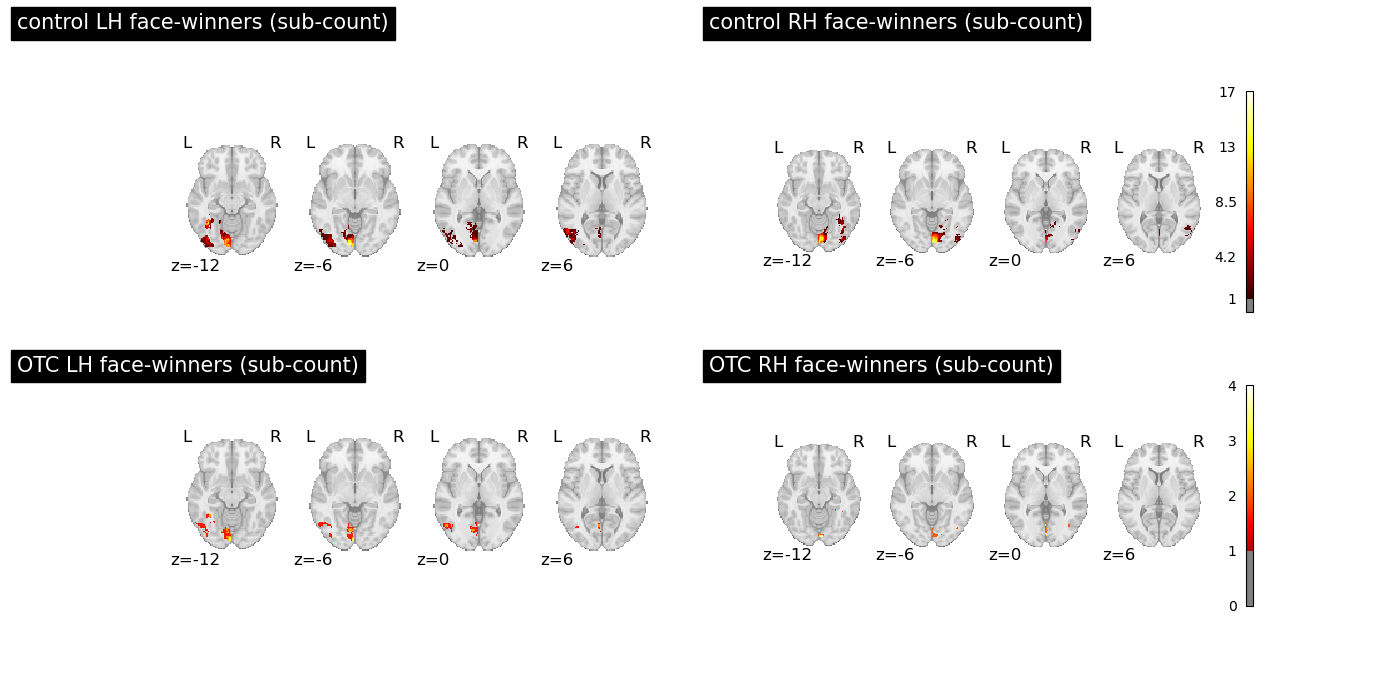

In [67]:
# ─── Where do face-winning voxels live per subject? ──────────────────────
# For each (subject, intact hemi), count face-winning voxels, find their
# centroid in MNI, compare distribution between patients and controls.
# Uses wta_data computed earlier in this notebook.

assert 'wta_data' in dir(), "Run the WTA compute cell first"

FACE_CODE = 1   # winner=1 means face won

def face_voxels_summary(d, mask_3d, affine):
    """For one subject×hemi: count of face-winners, centroid in MNI, extent."""
    winner = d['winner']
    # Reconstruct face-winner positions in 3D
    face_in_mask = (winner == FACE_CODE)
    n_face = int(face_in_mask.sum())
    if n_face == 0:
        return {'n_face': 0, 'mni_x': np.nan, 'mni_y': np.nan, 'mni_z': np.nan,
                'extent_mm': np.nan}
    # Get voxel indices of face-winners
    flat_idx_in_mask = np.where(face_in_mask)[0]
    mask_voxel_ijk = np.array(np.where(mask_3d)).T  # (n_mask_vox, 3)
    face_ijk = mask_voxel_ijk[flat_idx_in_mask]   # (n_face, 3)
    face_xyz = nib.affines.apply_affine(affine, face_ijk)
    centroid = face_xyz.mean(axis=0)
    bbox = face_xyz.max(axis=0) - face_xyz.min(axis=0)
    return {'n_face': n_face,
            'mni_x': centroid[0], 'mni_y': centroid[1], 'mni_z': centroid[2],
            'extent_mm': float(np.linalg.norm(bbox))}

rows = []
for (sid, h), d in wta_data.items():
    mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
    s = face_voxels_summary(d, mask, MNI_AFFINE)
    rows.append({'sid': sid, 'hemi': h, 'group': d['group'], **s})

df_face = pd.DataFrame(rows)

# Summary by group × hemi
print('Face-winning voxels per subject (WTA, threshold z>2.326):')
print(f"{'group':<10} {'hemi':>5} {'n':>3} {'mean_n_face':>12} {'sd_n_face':>10} "
      f"{'mean_centroid_xyz':>30}")
print('-' * 80)
for h in ['l', 'r']:
    for grp in ['control', 'OTC']:
        sub = df_face[(df_face.hemi == h) & (df_face.group == grp)]
        if len(sub) == 0: continue
        mean_n = sub['n_face'].mean()
        sd_n = sub['n_face'].std(ddof=1)
        cx, cy, cz = sub['mni_x'].mean(), sub['mni_y'].mean(), sub['mni_z'].mean()
        print(f"{grp:<10} {h.upper():>5} {len(sub):>3} {mean_n:>12.1f} {sd_n:>10.1f} "
              f"  ({cx:>5.0f}, {cy:>5.0f}, {cz:>5.0f})")

# Per-patient with face counts
print(f'\nPer-patient face-winner detail:')
print(f"{'sid':<12} {'intact':>7} {'n_face':>7} {'mni_xyz':>22} {'extent_mm':>10}")
for r in df_face[df_face.group == 'OTC'].itertuples():
    xyz = f'({r.mni_x:>4.0f},{r.mni_y:>4.0f},{r.mni_z:>4.0f})'
    print(f'{r.sid:<12} {r.hemi.upper():>7} {r.n_face:>7d} {xyz:>22} {r.extent_mm:>10.1f}')

# Plot face-winning voxels per group × hemi on brain
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for col, h in enumerate(['l', 'r']):
    mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
    for row, grp in enumerate(['control', 'OTC']):
        # Stack all face-winner masks for this group × hemi
        agg = np.zeros(mask.shape, dtype=np.int32)
        for (sid, hh), d in wta_data.items():
            if hh != h or d['group'] != grp: continue
            face_mask_flat = (d['winner'] == FACE_CODE).astype(np.int32)
            face_3d = np.zeros(mask.shape, dtype=np.int32)
            face_3d[mask] = face_mask_flat
            agg += face_3d
        # Plot as ROI (count map)
        agg_img = nib.Nifti1Image(agg.astype(np.float32), MNI_AFFINE)
        plotting.plot_stat_map(
            agg_img, axes=axes[row, col], display_mode='z',
            cut_coords=[-12, -6, 0, 6], threshold=1,
            title=f'{grp} {h.upper()}H face-winners (sub-count)',
            cmap='hot', colorbar=(col == 1),
        )
plt.tight_layout()
plt.show()

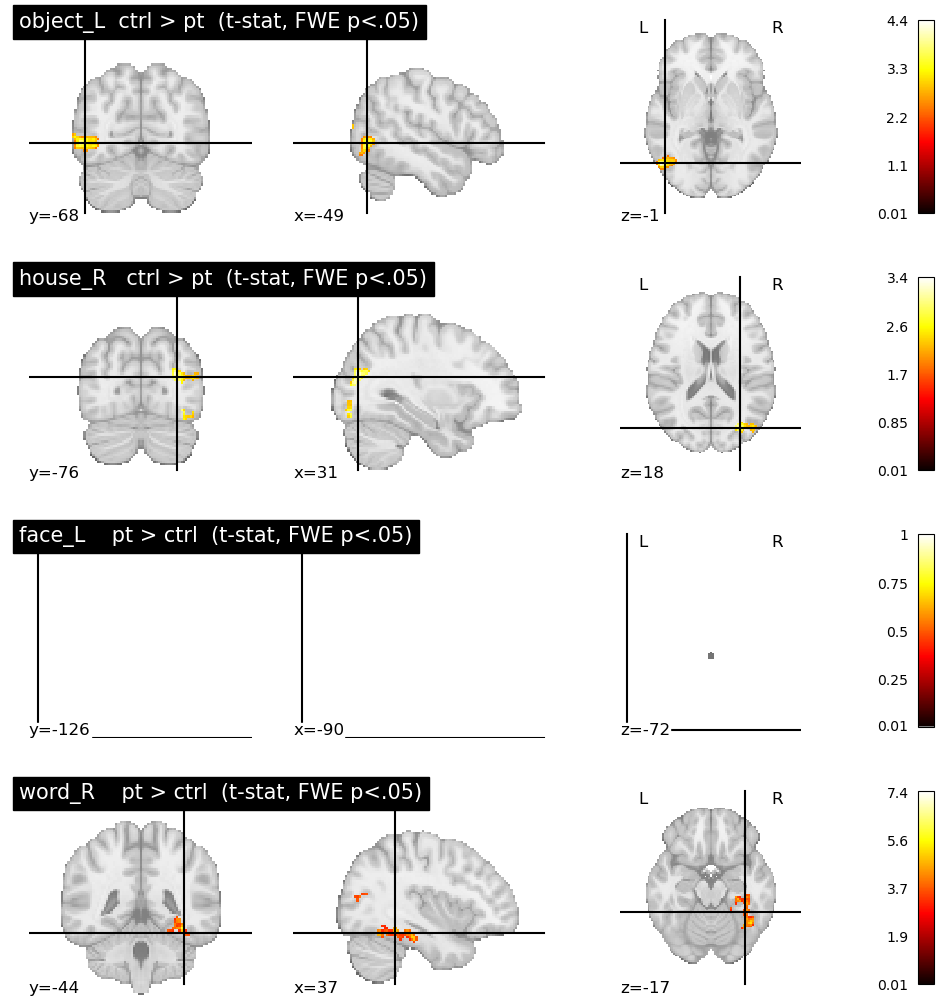

In [64]:
# ─── TFCE surviving clusters: FWE-significant t-stats on standard brain ──
# For each of the 4 surviving clusters, show the underlying t-statistic
# masked to voxels surviving FWE p<.05 (via TFCE correction, 10k perms).
#
# Per-cluster t-stat range is narrow (≈3–5), so vmax is set per panel
# rather than shared across panels — this maximizes visible contrast
# within each cluster but means colorbars aren't comparable across rows.
#
# Reads:
#   rand_tfce_corrp_tstat{N}.nii.gz  — used to mask to FWE-significant voxels
#   rand_tstat{N}.nii.gz             — raw t-statistic (requires -R flag in randomise)
#
# Layout: 4 rows × ortho (coronal/sagittal/axial) cuts through peak.
from nilearn import image
CLUSTERS = [
    ('object', 'l', 1, 'object_L  ctrl > pt'),
    ('house',  'r', 1, 'house_R   ctrl > pt'),
    ('face',   'l', 2, 'face_L    pt > ctrl'),
    ('word',   'r', 2, 'word_R    pt > ctrl'),
]

fig, axes = plt.subplots(len(CLUSTERS), 1, figsize=(12, 3.2 * len(CLUSTERS)))
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTERS):
    test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
    corrp_img = nib.load(test_dir / f'rand_tfce_corrp_tstat{tstat}.nii.gz')
    tstat_img = nib.load(test_dir / f'rand_tstat{tstat}.nii.gz')

    sig_mask = corrp_img.get_fdata() > 0.95
    tstat_data = tstat_img.get_fdata() * sig_mask
    masked = nib.Nifti1Image(tstat_data, tstat_img.affine)

    vmax = float(tstat_data.max()) if tstat_data.max() > 0 else 1.0
    plotting.plot_stat_map(
        masked, threshold=0.01, display_mode='ortho',
        colorbar=True, cmap='hot', vmax=vmax,
        title=f'{title}  (t-stat, FWE p<.05)', axes=ax,
    )
plt.show()

/tmp/ipykernel_3245307/1638852787.py:21: RuntimeWarning: invalid value encountered in divide
  t_map = np.where((se > 0) & mask, (cm - pm) / se, 0)


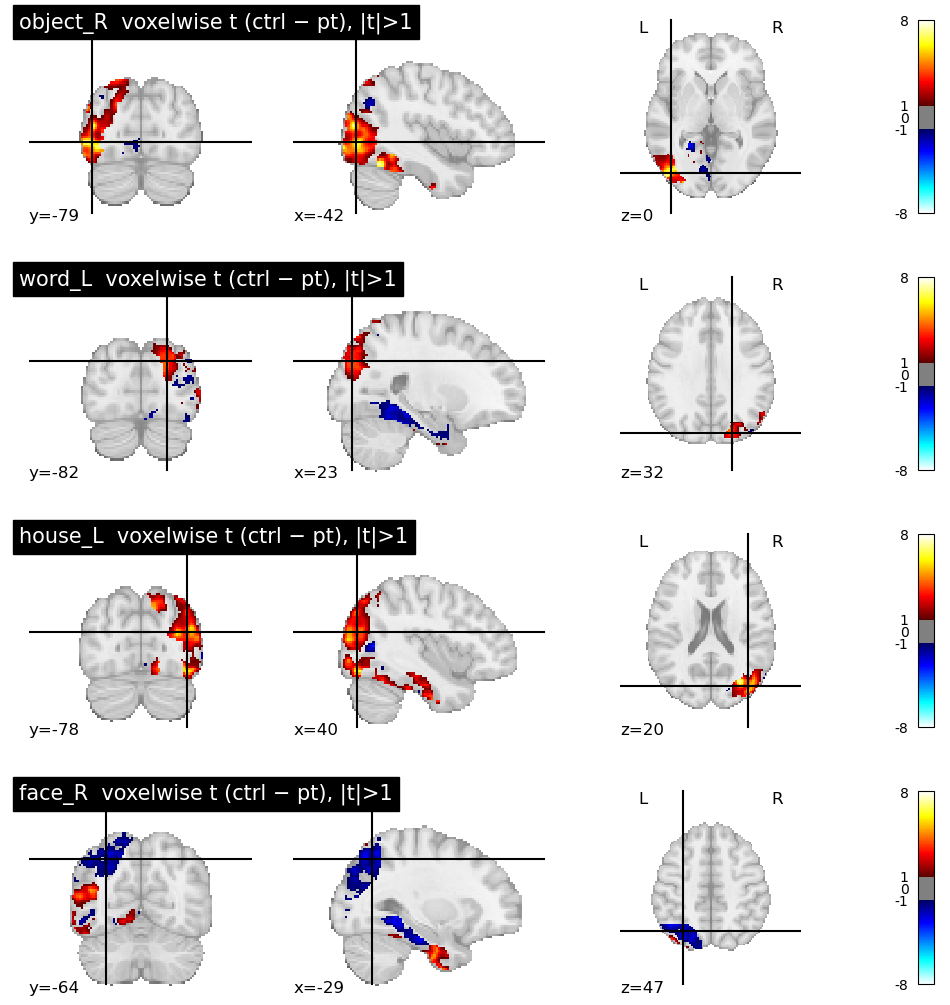

In [65]:
# ─── Spatial pattern of "null" tests: voxelwise t-map within VOTC ────────
# If diffuse: high-t voxels scattered, no clusters.
# If focal: high-t voxels clustered (suggests TFCE was over-conservative).

NULL_TESTS = [('object', 'r'), ('word', 'l'), ('house', 'l'), ('face', 'r')]

fig, axes = plt.subplots(len(NULL_TESTS), 1, figsize=(12, 3.2 * len(NULL_TESTS)))
for ax, (cat, hemi) in zip(axes, NULL_TESTS):
    test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
    merged = nib.load(test_dir / 'merged_zstat.nii.gz').get_fdata()
    mask = nib.load(TFCE_DIR / f'votc_{hemi}_mask.nii.gz').get_fdata() > 0.5

    with open(test_dir / 'design.mat') as f:
        lines = [l.strip() for l in f if l.strip() and not l.startswith('/')]
    n_c = sum(1 for l in lines if l == '1 0')

    cv = merged[..., :n_c]; pv = merged[..., n_c:]
    cm, pm = cv.mean(-1), pv.mean(-1)
    cvar, pvar = cv.var(-1, ddof=1), pv.var(-1, ddof=1)
    se = np.sqrt(cvar / n_c + pvar / pv.shape[-1])
    t_map = np.where((se > 0) & mask, (cm - pm) / se, 0)

    t_img = nib.Nifti1Image(t_map.astype(np.float32),
                            nib.load(test_dir / 'merged_zstat.nii.gz').affine)
    plotting.plot_stat_map(
        t_img, threshold=1.0, display_mode='ortho', # test different thresholds to see if pattern is diffuse (many scattered voxels) vs focal (clusters)
        colorbar=True, cmap='cold_hot', vmax=8,
        title=f'{cat}_{hemi.upper()}  voxelwise t (ctrl − pt), |t|>1',
        axes=ax,
    )
plt.show()

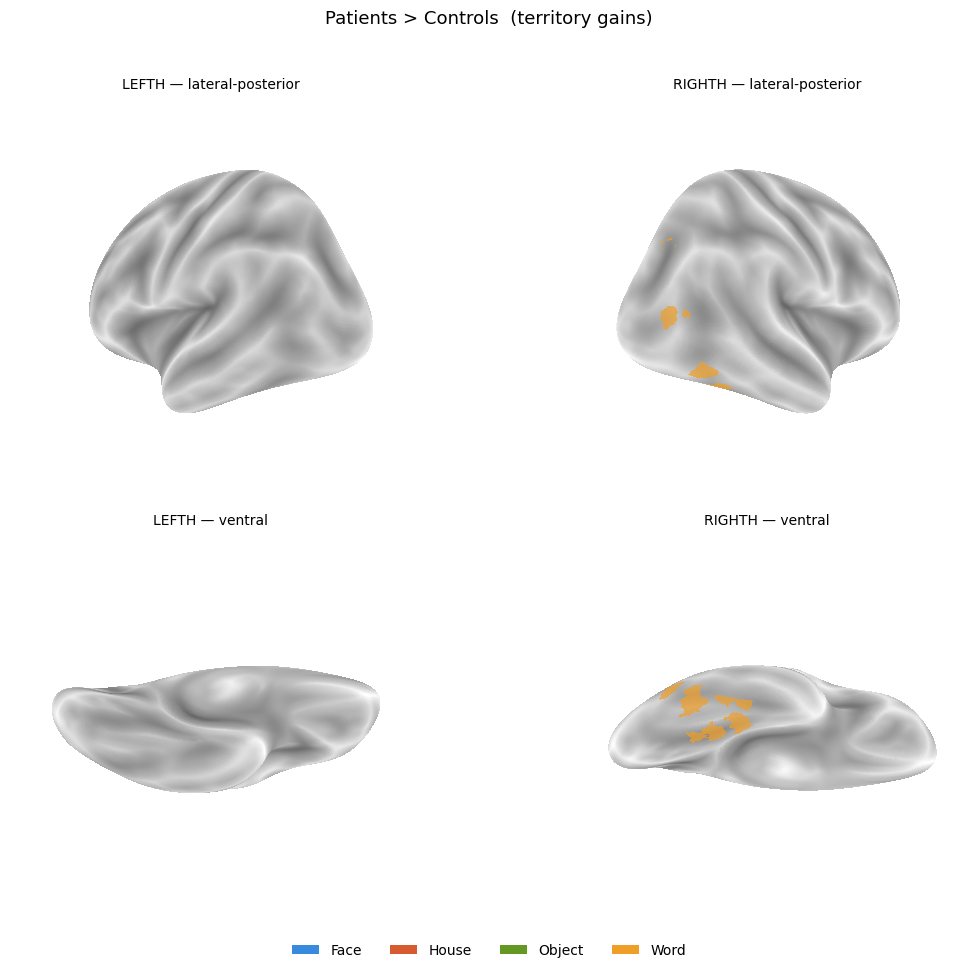

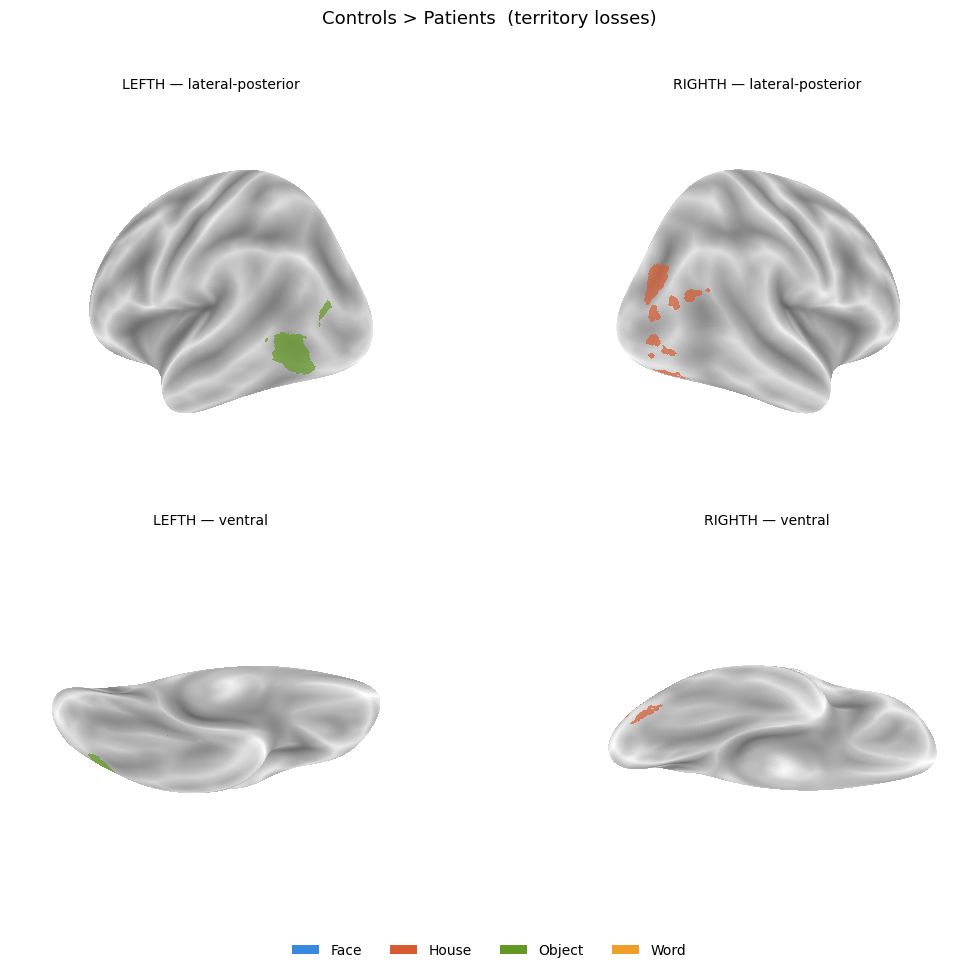

In [66]:
# ─── TFCE clusters: surface views (both hemis, lat-post + ventral) ───────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import datasets as nl_datasets, surface
from nilearn.plotting import plot_surf_roi

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CAT_INT = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

GAINS  = [('face',  'l', 2), ('word',  'r', 2)]
LOSSES = [('object','l', 1), ('house', 'r', 1)]

# Per-hemi view configs: (label, named_view, custom_elev_azim)
# custom_elev_azim is applied via view_init AFTER plot_surf_roi (overrides named view).
# Set to None to use the named view as-is.
VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in ['face','house','object','word']])


def project_clusters_to_surface(clusters, hemi):
    """Combine clusters in one hemisphere into a single surface map (vertex = CAT_INT)."""
    hemi_full = 'left' if hemi == 'l' else 'right'
    out = None
    for cat, h, tstat in clusters:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / f'rand_tfce_corrp_tstat{tstat}.nii.gz'
        vol_img = nib.load(fpath)
        sig = (vol_img.get_fdata() > 0.95).astype(np.float32)
        sig_img = nib.Nifti1Image(sig, vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        if out is None:
            out = np.zeros(surf_vals.shape, dtype=np.int16)
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out if out is not None else np.zeros(10242, dtype=np.int16)


for label, clusters in [('Patients > Controls  (territory gains)', GAINS),
                        ('Controls > Patients  (territory losses)', LOSSES)]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                             subplot_kw={'projection': '3d'})
    fig.suptitle(label, fontsize=13, y=0.98)

    for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
        roi_map = project_clusters_to_surface(clusters, hemi).astype(float)
        for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
            plot_surf_roi(
                fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=0.6,
                axes=axes[row, col], figure=fig,
            )
            # Override camera angle if custom view requested
            if view_custom is not None:
                elev, azim = view_custom
                axes[row, col].view_init(elev=elev, azim=azim)
            axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

    handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize())
               for c in ['face', 'house', 'object', 'word']]
    fig.legend(handles=handles, loc='lower center', ncol=4,
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.show()

WTA

In [77]:
# ─── WTA computation (Liu contrasts, per subject × hemi) ─────────────────
# Recomputes wta_data using SAME VOTC masks as tfce_votc_contrasts.py
# (loaded from TFCE_DIR/votc_{l,r}_mask.nii.gz) to ensure hemi labels
# match TFCE cluster files.

import os
from sym_pt_params import (skip_subs, get_sessions, is_patient,
                            get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word'] # note liu contrasts are all cat-vs-others, so same winner code (1) for all categories, not actual liu contrasts.
LIU_CONTRASTS = {'face': (6, False), 'house': (7, False),
                 'object': (8, False), 'word': (9, False)}
WTA_THRESHOLD = 2.326
EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

# ── Load VOTC masks (same as TFCE script used) ───────────────────────
_lh_img = nib.load(TFCE_DIR / 'votc_l_mask.nii.gz')
VOTC_MASK_LH = _lh_img.get_fdata() > 0.5
VOTC_MASK_RH = nib.load(TFCE_DIR / 'votc_r_mask.nii.gz').get_fdata() > 0.5
MNI_AFFINE = _lh_img.affine
MNI_SHAPE  = _lh_img.shape
print(f'LH VOTC: {VOTC_MASK_LH.sum():,} | RH VOTC: {VOTC_MASK_RH.sum():,}')

# ── Subject loader ────────────────────────────────────────────────────
def load_subjects_xs():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        group = info.get('group', 'unknown')
        if f"{group}{sc}" in EXTRA_SKIP or sid in EXTRA_SKIP or group == 'nonOTC':
            continue
        post_sessions = [f'{s:02d}' for s in sessions
                         if f'{s:02d}' not in PRE_SURGERY_SESSIONS.get(sid, set())]
        if not post_sessions:
            continue
        subjects[sid] = {
            'session': post_sessions[0], 'group': group,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects

# ── Compute WTA per subject × hemi ────────────────────────────────────
def _load_liu_zstats(sid, ses):
    vols = {}
    for cat, (cope, neg) in LIU_CONTRASTS.items():
        p = os.path.join(processed_dir, sid, f'ses-{ses}', 'derivatives', 'fsl',
                         'loc', 'HighLevel.gfeat', f'cope{cope}.feat', 'stats',
                         'zstat1_mni.nii.gz')
        if not os.path.exists(p):
            return None
        d = nib.load(p).get_fdata()
        vols[cat] = -d if neg else d
    return vols

def _compute_wta(vols, mask):
    z = np.stack([vols[c][mask] for c in CATEGORIES], axis=-1)
    max_z = z.max(axis=-1)
    winner = z.argmax(axis=-1) + 1
    winner[max_z < WTA_THRESHOLD] = 0
    sorted_z = np.sort(z, axis=-1)
    margin = sorted_z[:, -1] - sorted_z[:, -2]
    return winner, margin

subjects = load_subjects_xs()
ctrl_n = sum(1 for i in subjects.values() if i['group'] == 'control')
otc_n  = sum(1 for i in subjects.values() if i['group'] == 'OTC')
print(f'Subjects: {ctrl_n} ctrl + {otc_n} OTC')

wta_data, skipped = {}, []
for sid, info in subjects.items():
    vols = _load_liu_zstats(sid, info['session'])
    if vols is None:
        skipped.append(sid); continue
    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]
    for h in hemis:
        mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
        winner, margin = _compute_wta(vols, mask)
        wta_data[(sid, h)] = {
            'winner': winner, 'margin': margin,
            'n_voxels': int(mask.sum()),
            'group': info['group'],
            'surgery_side': info.get('surgery_side', 'na'),
        }
print(f'WTA: {len(wta_data)} sub-hemi entries' + (f' | skipped: {skipped}' if skipped else ''))

LH VOTC: 11,340 | RH VOTC: 11,540
Subjects: 38 ctrl + 25 OTC
WTA: 98 sub-hemi entries | skipped: ['sub-098', 'sub-101', 'sub-109']


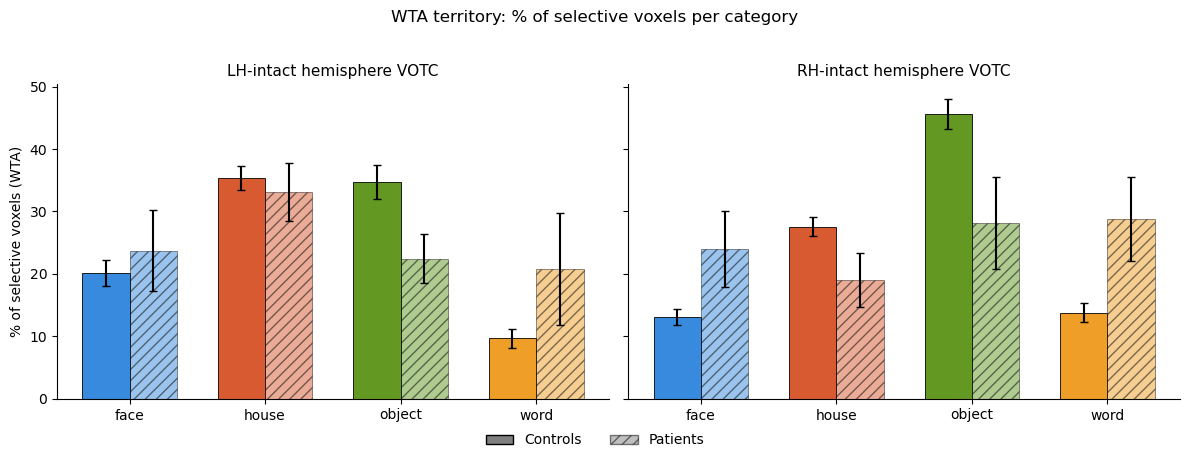

In [78]:
# ─── WTA territory: % of selective voxels per category × hemi × group ────
# Uses wta_data dict from voxel_allegiance_xs_liu notebook (cells 2, 4, 6).
# Each (sid, hemi) entry has 'winner' (0=below thresh, 1-4=face/house/object/word).

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

assert 'wta_data' in dir(), "Run cells 2, 4, 6 from voxel_allegiance_xs_liu first"

# Build per-subject territory % table
terr_rows = []
for (sid, h), d in wta_data.items():
    winner = d['winner']
    selective = winner > 0
    n_sel = selective.sum()
    for i, cat in enumerate(CATEGORIES, start=1):
        pct = 100 * (winner == i).sum() / n_sel if n_sel else np.nan
        terr_rows.append({'sid': sid, 'hemi': h, 'category': cat,
                          'pct': pct, 'group': d['group']})
terr_df = pd.DataFrame(terr_rows)

# Plot: 1×2 (LH, RH), each with grouped bars (ctrl vs pt) per category
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, h, hlabel in zip(axes, ['l', 'r'], ['LH-intact', 'RH-intact']):
    sub = terr_df[terr_df['hemi'] == h]
    x = np.arange(len(CATEGORIES))
    w = 0.35
    for offset, grp, alpha, hatch in [(-w/2, 'control', 1.0, ''),
                                       (+w/2, 'OTC',     0.5, '///')]:
        means = [sub[(sub['category']==c) & (sub['group']==grp)]['pct'].mean()
                 for c in CATEGORIES]
        sems  = [sub[(sub['category']==c) & (sub['group']==grp)]['pct'].sem()
                 for c in CATEGORIES]
        ax.bar(x + offset, means, w, yerr=sems,
               color=[CAT_COLORS[c] for c in CATEGORIES],
               alpha=alpha, hatch=hatch, edgecolor='black', linewidth=0.6, capsize=3)
    ax.set_xticks(x); ax.set_xticklabels(CATEGORIES, fontsize=10)
    ax.set_title(f'{hlabel} hemisphere VOTC', fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if h == 'l':
        ax.set_ylabel('% of selective voxels (WTA)', fontsize=10)

style_handles = [
    Patch(facecolor='gray', edgecolor='black', label='Controls'),
    Patch(facecolor='gray', alpha=0.5, edgecolor='black', hatch='///', label='Patients'),
]
fig.legend(handles=style_handles, ncol=2, frameon=False, fontsize=10,
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
fig.suptitle('WTA territory: % of selective voxels per category', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

/tmp/ipykernel_3245307/2470379250.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.97])


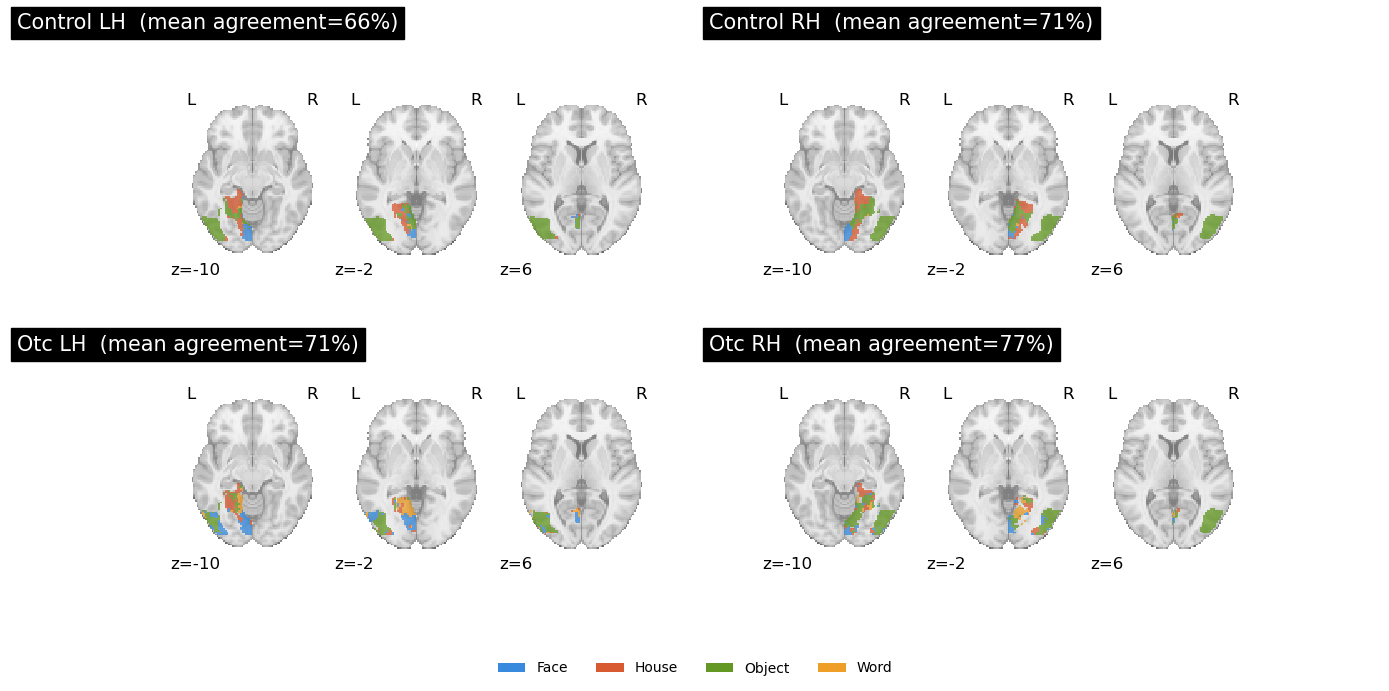

In [ ]:
# ─── WTA watercolor: group mode winner + agreement on standard brain ────
# For each voxel in VOTC: most common winning category across subjects (color),
# with opacity scaled by agreement %. Computed per hemi × group.

from matplotlib.colors import ListedColormap, to_rgba
from scipy.stats import mode

assert 'wta_data' in dir(), "Run cells 2, 4, 6 from voxel_allegiance_xs_liu first"
assert 'VOTC_MASK_LH' in dir() and 'MNI_AFFINE' in dir(), \
    "Run cell 4 from voxel_allegiance_xs_liu first (defines masks + affine)"

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

def build_group_wta_3d(group_label, hemi):
    """Per voxel: mode winner across subjects + fraction agreement.
    Returns (winner_3d int, agreement_3d float) shaped like MNI volume."""
    mask = VOTC_MASK_LH if hemi == 'l' else VOTC_MASK_RH
    # Stack winners (n_sub, n_vox) for this group × hemi
    stacked = np.stack([d['winner'] for (sid, h), d in wta_data.items()
                        if h == hemi and d['group'] == group_label])
    # Per-voxel mode (1-4) and agreement (frac winning category)
    mode_vals = np.zeros(stacked.shape[1], dtype=np.int16)
    agree     = np.zeros(stacked.shape[1], dtype=np.float32)
    for v in range(stacked.shape[1]):
        col = stacked[:, v]
        col_sel = col[col > 0]
        if len(col_sel) == 0:
            continue
        vals, counts = np.unique(col_sel, return_counts=True)
        top = np.argmax(counts)
        mode_vals[v] = vals[top]
        agree[v] = counts[top] / len(col_sel)
    # Project back to 3D
    out_winner = np.zeros(mask.shape, dtype=np.int16); out_winner[mask] = mode_vals
    out_agree  = np.zeros(mask.shape, dtype=np.float32); out_agree[mask] = agree
    return out_winner, out_agree

# Build RGBA volume: color from winner, alpha from agreement
def make_rgba_volume(winner, agree):
    rgba = np.zeros(winner.shape + (4,), dtype=np.float32)
    for i, cat in enumerate(CATEGORIES, start=1):
        r, g, b, _ = to_rgba(CAT_COLORS[cat])
        sel = winner == i
        rgba[sel, 0] = r; rgba[sel, 1] = g; rgba[sel, 2] = b
        rgba[sel, 3] = agree[sel]
    return rgba

# Build categorical NIfTI per group×hemi (just for nilearn plot_roi)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
cat_cmap = ListedColormap([CAT_COLORS[c] for c in CATEGORIES])

for col, (h, hlabel) in enumerate([('l', 'LH'), ('r', 'RH')]):
    for row, grp in enumerate(['control', 'OTC']):
        winner, agree = build_group_wta_3d(grp, h)
        # alpha as fade is hard with plot_roi; use winner as ROI map at fixed alpha
        # and overlay text giving agreement summary
        roi_img = nib.Nifti1Image(winner.astype(np.int16), MNI_AFFINE)
        cut_z = -10 if h == 'l' else -10  # ventral slice
        plotting.plot_roi(
            roi_img, cmap=cat_cmap, alpha=0.75,
            vmin=0.5, vmax=4.5,
            display_mode='z', cut_coords=[cut_z, -2, 6],
            axes=axes[row, col],
            title=f'{grp.capitalize()} {hlabel}  (mean agreement={agree[winner>0].mean():.0%})',
            annotate=True, draw_cross=False,
        )

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
fig.legend(handles=handles, ncol=4, frameon=False, fontsize=10,
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

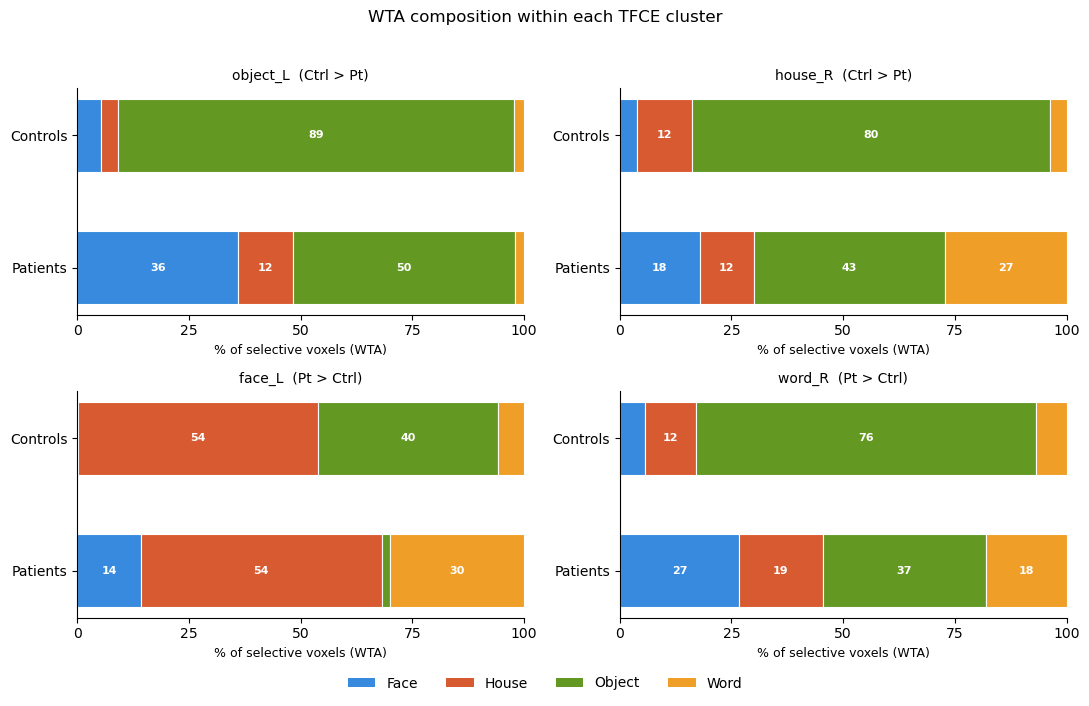


cluster      group        face    house   object     word
object_L     Ctrl         5.2%     3.8%    88.7%     2.3%
object_L     Pt          36.1%    12.2%    49.6%     2.1%
house_R      Ctrl         4.0%    12.3%    80.0%     3.7%
house_R      Pt          17.9%    12.0%    42.9%    27.2%
face_L       Ctrl         0.1%    53.7%    40.4%     5.8%
face_L       Pt          14.3%    53.8%     1.9%    30.0%
word_R       Ctrl         5.6%    11.5%    76.0%     6.9%
word_R       Pt          26.7%    18.7%    36.6%    18.0%


In [ ]:
# ─── WTA composition inside each TFCE cluster ────────────────────────────
# For each surviving TFCE cluster: what % of voxels are won by each
# category, in controls vs matched-hemi patients. Uses group mode WTA
# (computed in previous cell).

assert 'wta_data' in dir(), "Run cells 2, 4, 6 from voxel_allegiance_xs_liu first"
assert 'MNI_AFFINE' in dir(), "Run cell 4 from voxel_allegiance_xs_liu first"

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

CLUSTERS = [
    ('object', 'l', 1, 'Ctrl > Pt'),
    ('house',  'r', 1, 'Ctrl > Pt'),
    ('face',   'l', 2, 'Pt > Ctrl'),
    ('word',   'r', 2, 'Pt > Ctrl'),
]

def group_winner_at_mask(group_label, hemi, cluster_mask_3d):
    """Per subject in group×hemi: composition % per category at cluster voxels.
    Returns dict {cat: per_subject_array}."""
    mask = VOTC_MASK_LH if hemi == 'l' else VOTC_MASK_RH
    # cluster_mask_3d intersected with hemi votc mask, then mapped to flat indices
    cluster_in_mask = cluster_mask_3d[mask]   # bool, len = n_votc_vox
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        winner_in_cluster = d['winner'][cluster_in_mask]
        sel = winner_in_cluster > 0
        n_sel = sel.sum()
        for i, cat in enumerate(CATEGORIES, start=1):
            pct = 100 * (winner_in_cluster == i).sum() / n_sel if n_sel else np.nan
            per_cat[cat].append(pct)
    return {c: np.array(v) for c, v in per_cat.items()}

rows = []
for cat, hemi, tstat, dir_label in CLUSTERS:
    cluster_path = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl' / f'rand_tfce_corrp_tstat{tstat}.nii.gz'
    cluster_mask = nib.load(cluster_path).get_fdata() > 0.95

    ctrl_comp = group_winner_at_mask('control', hemi, cluster_mask)
    pt_comp   = group_winner_at_mask('OTC',     hemi, cluster_mask)

    row = {'cluster': f'{cat}_{hemi.upper()}', 'direction': dir_label}
    for c in CATEGORIES:
        row[f'ctrl_{c}_mean'] = np.nanmean(ctrl_comp[c])
        row[f'ctrl_{c}_sem']  = np.nanstd(ctrl_comp[c], ddof=1) / np.sqrt(len(ctrl_comp[c]))
        row[f'pt_{c}_mean']   = np.nanmean(pt_comp[c])
        row[f'pt_{c}_sem']    = np.nanstd(pt_comp[c], ddof=1) / np.sqrt(len(pt_comp[c]))
    rows.append(row)

# Plot: 2x2, one panel per cluster, stacked bar ctrl vs pt
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for ax, r in zip(axes, rows):
    for prefix, y in [('ctrl', 1), ('pt', 0)]:
        left = 0
        for c in CATEGORIES:
            w = r[f'{prefix}_{c}_mean']
            ax.barh(y, w, left=left, height=0.55, color=CAT_COLORS[c],
                    edgecolor='white', linewidth=0.8)
            if w >= 8:
                ax.text(left + w/2, y, f'{w:.0f}', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
            left += w
    ax.set_yticks([1, 0]); ax.set_yticklabels(['Controls', 'Patients'], fontsize=10)
    ax.set_xlim(0, 100); ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel('% of selective voxels (WTA)', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.set_title(f"{r['cluster']}  ({r['direction']})", fontsize=10)

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
fig.legend(handles=handles, ncol=4, frameon=False, fontsize=10,
           loc='lower center', bbox_to_anchor=(0.5, -0.01))
fig.suptitle('WTA composition within each TFCE cluster', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Print summary
print(f"\n{'cluster':<12} {'group':<8} " + ' '.join(f'{c:>8}' for c in CATEGORIES))
for r in rows:
    for prefix, label in [('ctrl', 'Ctrl'), ('pt', 'Pt')]:
        vals = ' '.join(f'{r[f"{prefix}_{c}_mean"]:>7.1f}%' for c in CATEGORIES)
        print(f"{r['cluster']:<12} {label:<8} {vals}")

/tmp/ipykernel_3245307/2373813150.py:73: RuntimeWarning: Mean of empty slice
  h = np.nanmean(comp[c])


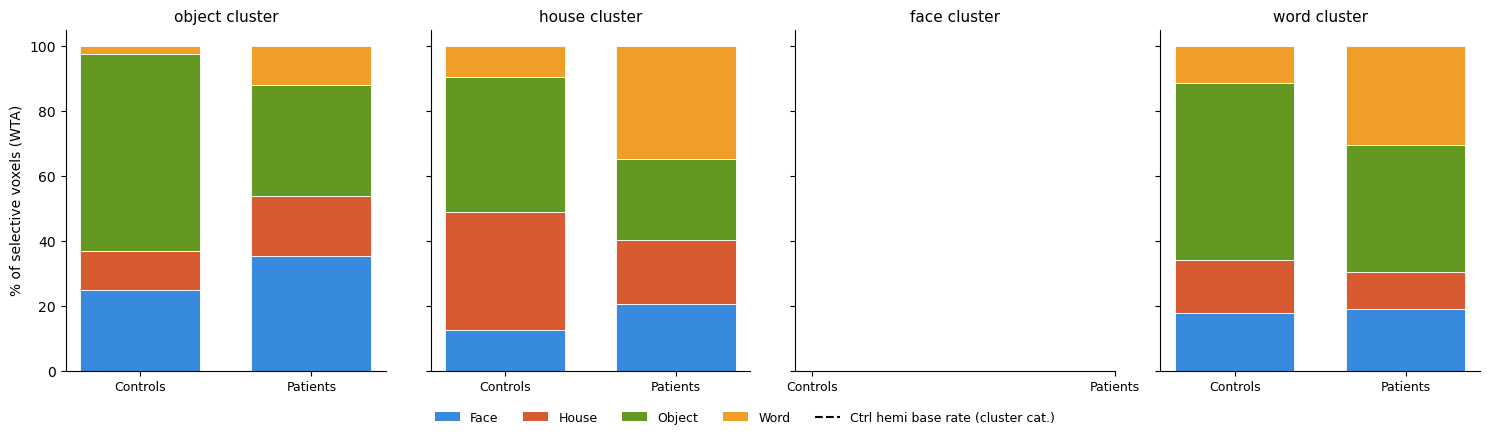

In [79]:
# ─── WTA composition bars (Liu-style, per cluster) ──────────────────────
# Stacked bars per cluster (ctrl + pt side-by-side), dashed reference line
# at hemisphere base rate for the cluster's defining category.
#
# REQUIRES: wta_data with correct masks (load votc_l_mask.nii.gz from
# TFCE_DIR; do NOT use voxel_allegiance's VOTC_MASK_LH/RH if convention
# differs).

from matplotlib.patches import Patch

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

CLUSTERS = [
    ('object', 'l', 1, 'object cluster'),
    ('house',  'r', 1, 'house cluster'),
    ('face',   'l', 2, 'face cluster'),
    ('word',   'r', 2, 'word cluster'),
]

def composition_at_mask(group_label, hemi, cluster_3d_mask, hemi_3d_mask):
    """Returns dict {cat: per_subject_pct_array} at cluster voxels.
    cluster_3d_mask, hemi_3d_mask: 3D bool arrays, same MNI space.
    Subject winners are 1D, ordered by hemi_3d_mask.flatten() True positions."""
    cluster_in_hemi = cluster_3d_mask[hemi_3d_mask]   # 1D bool, length=hemi_mask.sum()
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        if len(d['winner']) != len(cluster_in_hemi):
            continue  # mask mismatch — skip
        w = d['winner'][cluster_in_hemi]
        sel = w > 0
        n = sel.sum()
        for i, cat in enumerate(CATEGORIES, start=1):
            pct = 100 * (w == i).sum() / n if n else np.nan
            per_cat[cat].append(pct)
    return {c: np.array(v) for c, v in per_cat.items()}

def hemi_base_rate(group_label, hemi):
    """Across-subject mean % of selective voxels per category in full hemi VOTC."""
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        w = d['winner']
        sel = w > 0
        n = sel.sum()
        for i, cat in enumerate(CATEGORIES, start=1):
            per_cat[cat].append(100 * (w == i).sum() / n if n else np.nan)
    return {c: np.nanmean(v) for c, v in per_cat.items()}

# Build composition per cluster, using TFCE-script masks
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5), sharey=True)

for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTERS):
    cluster_3d = nib.load(TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl' /
                          f'rand_tfce_corrp_tstat{tstat}.nii.gz').get_fdata() > 0.95
    hemi_3d    = nib.load(TFCE_DIR / f'votc_{hemi}_mask.nii.gz').get_fdata() > 0.5

    ctrl_comp = composition_at_mask('control', hemi, cluster_3d, hemi_3d)
    pt_comp   = composition_at_mask('OTC',     hemi, cluster_3d, hemi_3d)
    #ctrl_base = hemi_base_rate('control', hemi)

    # Build stacked bars
    x_pos = [0, 1]
    bar_labels = ['Controls', 'Patients']
    comps = [ctrl_comp, pt_comp]
    for xi, comp in zip(x_pos, comps):
        bottom = 0
        for c in CATEGORIES:
            h = np.nanmean(comp[c])
            ax.bar(xi, h, bottom=bottom, width=0.7, color=CAT_COLORS[c],
                   edgecolor='white', linewidth=0.6)
            bottom += h

    # Dashed reference line: hemisphere base rate for cluster's defining category
    #ax.axhline(ctrl_base[cat], color='black', linestyle='--', linewidth=1, alpha=0.7)

    ax.set_xticks(x_pos); ax.set_xticklabels(bar_labels, fontsize=9)
    ax.set_ylim(0, 105); ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[0].set_ylabel('% of selective voxels (WTA)', fontsize=10)

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
handles.append(plt.Line2D([0], [0], color='black', linestyle='--',
                          label='Ctrl hemi base rate (cluster cat.)'))
fig.legend(handles=handles, ncol=5, frameon=False, fontsize=9,
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

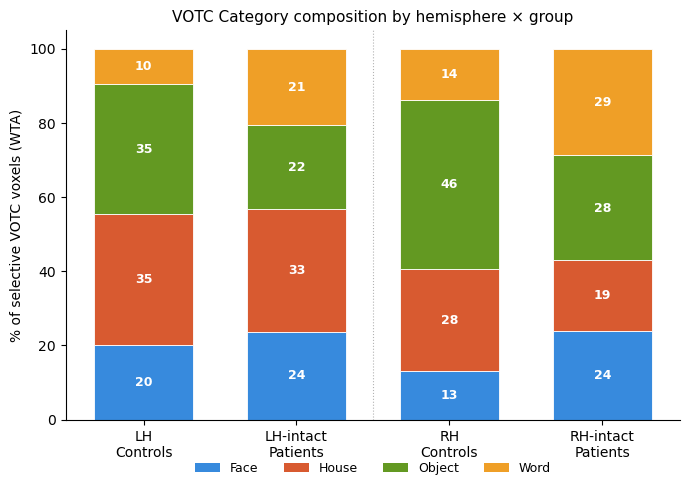


condition                     face     house    object      word
LH Controls                  20.2%     35.3%     34.8%      9.7%
LH-intact Patients           23.7%     33.1%     22.4%     20.7%
RH Controls                  13.1%     27.6%     45.6%     13.8%
RH-intact Patients           24.0%     19.0%     28.1%     28.8%


In [80]:
# ─── Total VOTC composition: stacked bars by hemi × group ────────────────
from matplotlib.patches import Patch

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

def composition(group_label, hemi):
    """Per-subject % of selective VOTC voxels per category. Returns dict."""
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        w = d['winner']
        n = (w > 0).sum()
        for i, c in enumerate(CATEGORIES, start=1):
            per_cat[c].append(100 * (w == i).sum() / n if n else np.nan)
    return per_cat

CONDITIONS = [
    ('control', 'l', 'LH\nControls'),
    ('OTC',     'l', 'LH-intact\nPatients'),
    ('control', 'r', 'RH\nControls'),
    ('OTC',     'r', 'RH-intact\nPatients'),
]

fig, ax = plt.subplots(figsize=(7, 5))
for i, (grp, hemi, label) in enumerate(CONDITIONS):
    comp = composition(grp, hemi)
    bottom = 0
    for c in CATEGORIES:
        mean_pct = np.nanmean(comp[c])
        sem_pct  = np.nanstd(comp[c], ddof=1) / np.sqrt(len(comp[c]))
        ax.bar(i, mean_pct, bottom=bottom, width=0.65, color=CAT_COLORS[c],
               edgecolor='white', linewidth=0.6)
        if mean_pct >= 5:
            ax.text(i, bottom + mean_pct/2, f'{mean_pct:.0f}',
                    ha='center', va='center', fontsize=9, color='white',
                    fontweight='bold')
        bottom += mean_pct

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([c[2] for c in CONDITIONS], fontsize=10)
ax.set_ylabel('% of selective VOTC voxels (WTA)', fontsize=10)
ax.set_ylim(0, 105)
ax.set_title('VOTC Category composition by hemisphere × group', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Visual divider between LH and RH groups
ax.axvline(1.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
ax.legend(handles=handles, ncol=4, frameon=False, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# Print numerical summary
print(f"\n{'condition':<24} " + ' '.join(f'{c:>9}' for c in CATEGORIES))
for grp, hemi, label in CONDITIONS:
    comp = composition(grp, hemi)
    means = [np.nanmean(comp[c]) for c in CATEGORIES]
    label_flat = label.replace('\n', ' ')
    print(f"{label_flat:<24} " + ' '.join(f'{m:>8.1f}%' for m in means))

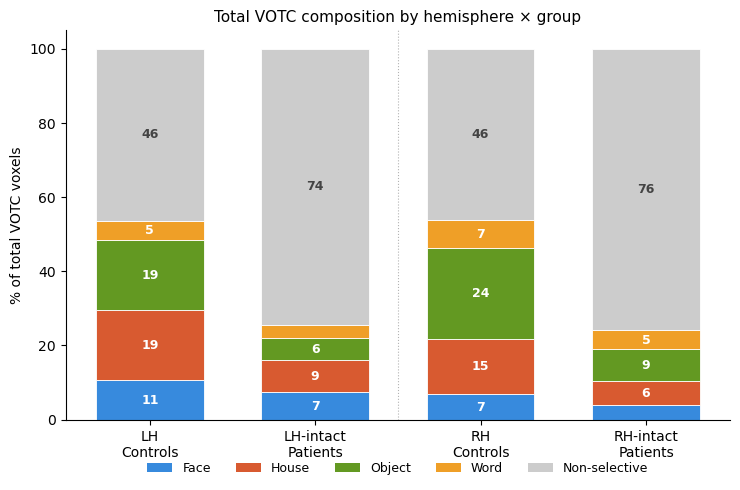


condition                       face       house      object        word non-selective
LH Controls                    10.6%       18.9%       19.0%        5.2%       46.4%
LH-intact Patients              7.4%        8.6%        5.9%        3.6%       74.4%
RH Controls                     6.9%       14.9%       24.4%        7.5%       46.3%
RH-intact Patients              4.0%        6.3%        8.7%        5.1%       75.9%


In [81]:
# ─── Total VOTC composition with non-selective: hemi × group ─────────────
from matplotlib.patches import Patch

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
NONSEL_COLOR = '#cccccc'

def composition_full(group_label, hemi):
    """% of ALL VOTC voxels per category, including non-selective."""
    per_cat = {c: [] for c in CATEGORIES}
    nonsel = []
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        w = d['winner']
        n_total = len(w)
        for i, c in enumerate(CATEGORIES, start=1):
            per_cat[c].append(100 * (w == i).sum() / n_total)
        nonsel.append(100 * (w == 0).sum() / n_total)
    per_cat['non-selective'] = nonsel
    return per_cat

CONDITIONS = [
    ('control', 'l', 'LH\nControls'),
    ('OTC',     'l', 'LH-intact\nPatients'),
    ('control', 'r', 'RH\nControls'),
    ('OTC',     'r', 'RH-intact\nPatients'),
]
STACK_ORDER = CATEGORIES + ['non-selective']
STACK_COLORS = {**CAT_COLORS, 'non-selective': NONSEL_COLOR}

fig, ax = plt.subplots(figsize=(7.5, 5))
for i, (grp, hemi, label) in enumerate(CONDITIONS):
    comp = composition_full(grp, hemi)
    bottom = 0
    for c in STACK_ORDER:
        mean_pct = np.nanmean(comp[c])
        ax.bar(i, mean_pct, bottom=bottom, width=0.65, color=STACK_COLORS[c],
               edgecolor='white', linewidth=0.6)
        if mean_pct >= 5:
            text_color = '#444' if c == 'non-selective' else 'white'
            ax.text(i, bottom + mean_pct/2, f'{mean_pct:.0f}',
                    ha='center', va='center', fontsize=9, color=text_color,
                    fontweight='bold')
        bottom += mean_pct

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([c[2] for c in CONDITIONS], fontsize=10)
ax.set_ylabel('% of total VOTC voxels', fontsize=10)
ax.set_ylim(0, 105)
ax.set_title('Total VOTC composition by hemisphere × group', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.axvline(1.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

handles = [Patch(facecolor=STACK_COLORS[c],
                 label=c.capitalize() if c != 'non-selective' else 'Non-selective')
           for c in STACK_ORDER]
ax.legend(handles=handles, ncol=5, frameon=False, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'condition':<24} " + ' '.join(f'{c:>11}' for c in STACK_ORDER))
for grp, hemi, label in CONDITIONS:
    comp = composition_full(grp, hemi)
    means = [np.nanmean(comp[c]) for c in STACK_ORDER]
    label_flat = label.replace('\n', ' ')
    print(f"{label_flat:<24} " + ' '.join(f'{m:>10.1f}%' for m in means))